In [1]:
# Run once
!pip install mlflow scikit-learn xgboost pandas numpy matplotlib seaborn imbalanced-learn evidently

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, f1_score, precision_score, recall_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.3/10.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.6 MB 1.7 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/10.6 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/10.6 MB 1.9 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/10.6 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/10.6 MB 2.1 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/10.6 MB 2.3 MB/s eta 0:00:04
   -------------- ------------------------- 3.9/10.6 MB 2.5 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/10.6 MB 2.6 MB/s eta 0:00:03
   ------------------- ------------

In [7]:
df = pd.read_csv('../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Churn'].value_counts(normalize=True))  # check class imbalance
df.head()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


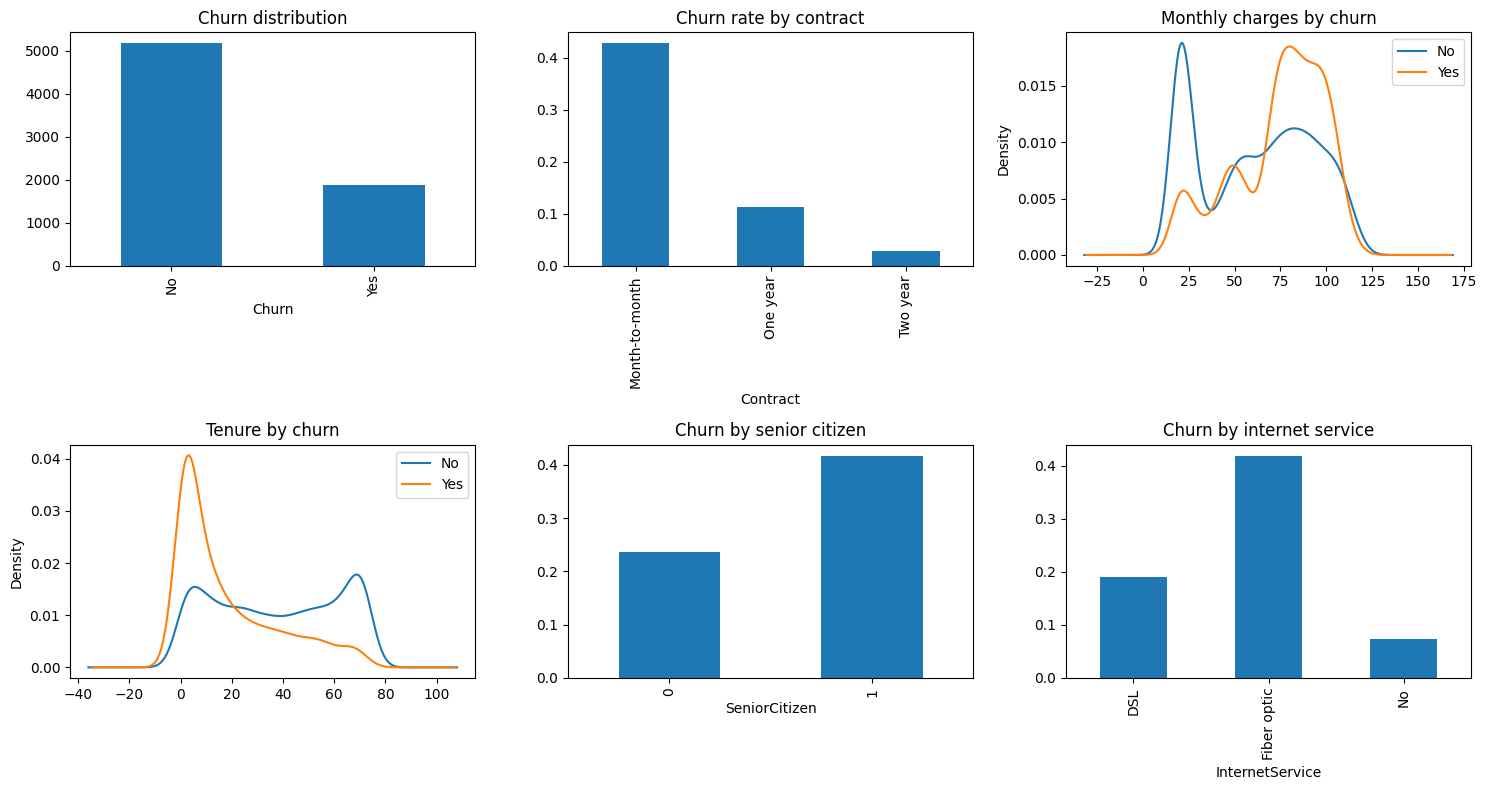

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], title='Churn distribution')

# Churn by contract type
df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(
    kind='bar', ax=axes[0,1], title='Churn rate by contract')

# Monthly charges distribution
df.groupby('Churn')['MonthlyCharges'].plot(kind='kde', ax=axes[0,2], legend=True,
                                            title='Monthly charges by churn')

# Tenure distribution
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[1,0], legend=True,
                                   title='Tenure by churn')

# Senior citizen churn rate
df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(
    kind='bar', ax=axes[1,1], title='Churn by senior citizen')

# Internet service churn
df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(
    kind='bar', ax=axes[1,2], title='Churn by internet service')

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150)
plt.show()

In [9]:
def preprocess(df):
    df = df.copy()
    
    # Drop customerID — it's just an identifier
    df.drop('customerID', axis=1, inplace=True)
    
    # Fix TotalCharges — it has spaces that prevent numeric conversion
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    
    # Target encoding: Yes → 1, No → 0
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)
    
    # Binary columns
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        df[col] = (df[col].isin(['Male', 'Yes'])).astype(int)
    
    # Multi-class categorical → label encode
    cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    
    return df

df_clean = preprocess(df)
print(df_clean.shape)
print(df_clean.dtypes)
df_clean.head()

(7043, 20)
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [23]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE to handle the ~26% / 74% imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Training set after SMOTE: {X_train_res.shape}")
print(f"Churn rate in training: {y_train_res.mean():.2%}")

# Save test set as reference for drift detection later
X_test.to_csv('../data/reference_data.csv', index=False)

Training set after SMOTE: (8278, 19)
Churn rate in training: 50.00%


In [27]:
import os
import socket
from urllib.parse import urlparse
import mlflow

local_store = os.path.abspath("./mlruns")
os.makedirs(local_store, exist_ok=True)
os.makedirs(os.path.join(local_store, ".trash"), exist_ok=True)

tracking_uri = os.getenv("MLFLOW_TRACKING_URI", f"file:{local_store}")
if tracking_uri.startswith("http"):
    parsed = urlparse(tracking_uri)
    host = parsed.hostname or "localhost"
    port = parsed.port or (443 if parsed.scheme == "https" else 80)
    sock = socket.socket()
    sock.settimeout(1)
    try:
        sock.connect((host, port))
    except OSError:
        tracking_uri = f"file:{local_store}"
    finally:
        sock.close()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("churn_prediction")

models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "xgboost": XGBClassifier(n_estimators=100, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='logloss',
                              random_state=42)
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

results = {}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Train
        model.fit(X_train_scaled, y_train_res)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Metrics
        metrics = {
            "roc_auc":   roc_auc_score(y_test, y_proba),
            "f1_score":  f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall":    recall_score(y_test, y_pred),
        }
        
        # Log to MLflow
        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, "model",
                                  registered_model_name=f"churn_{name}")
        
        # Save scaler as artifact too
        import pickle, os
        os.makedirs("artifacts", exist_ok=True)
        with open("artifacts/scaler.pkl", "wb") as f:
            pickle.dump(scaler, f)
        mlflow.log_artifact("artifacts/scaler.pkl")
        
        results[name] = metrics
        print(f"\n{name}:")
        print(classification_report(y_test, y_pred))

# Show comparison
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

2026/05/29 13:49:08 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction' does not exist. Creating a new experiment.
2026/05/29 13:49:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 13:49:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'churn_logistic_regression'.
Created version '1' of model 'churn_logistic_regression'.



logistic_regression:
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.71      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



2026/05/29 13:49:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 13:49:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'churn_random_forest'.
Created version '1' of model 'churn_random_forest'.



random_forest:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.58      0.57      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.78      0.78      1409



2026/05/29 13:49:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 13:49:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



xgboost:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.56      0.61      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



Successfully registered model 'churn_xgboost'.
Created version '1' of model 'churn_xgboost'.


,roc_auc,f1_score,precision,recall
xgboost,0.827580,0.585678,0.561275,0.612299
random_forest,0.823783,0.573748,0.580822,0.566845
logistic_regression,0.822202,0.603390,0.522505,0.713904


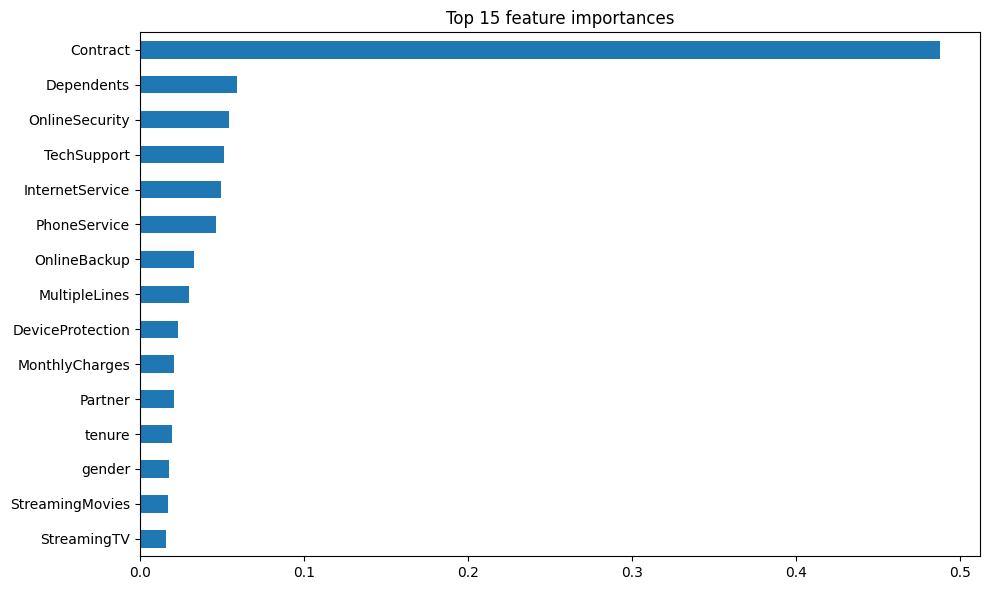

In [28]:
best_model = models['xgboost']

feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(10, 6), title='Top 15 feature importances')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

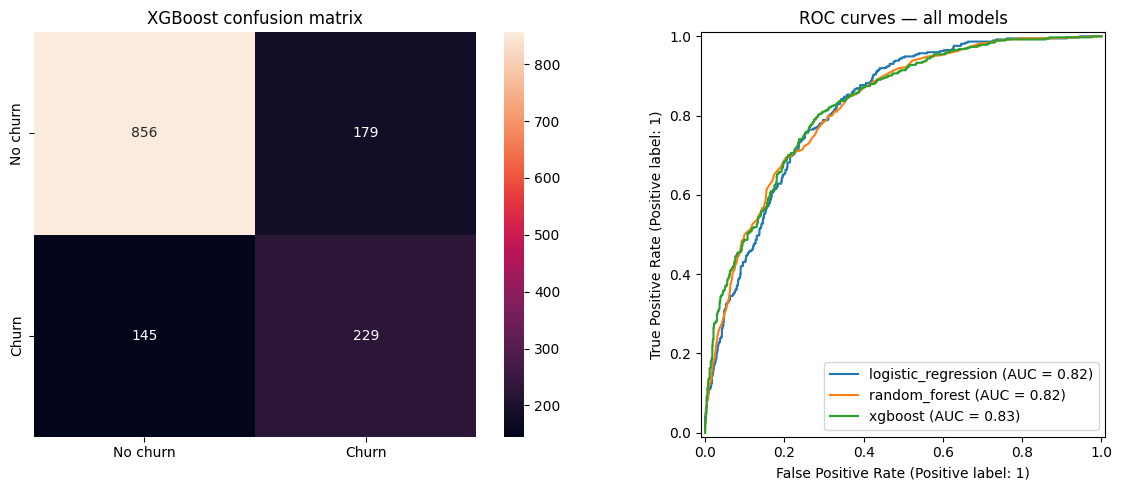

In [29]:
from sklearn.metrics import RocCurveDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, models['xgboost'].predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', ax=ax1,
            xticklabels=['No churn','Churn'],
            yticklabels=['No churn','Churn'])
ax1.set_title('XGBoost confusion matrix')

# ROC curve for all models
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test,
                                    name=name, ax=ax2)
ax2.set_title('ROC curves — all models')
plt.tight_layout()
plt.show()

In [30]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Find run with highest AUC
experiment = client.get_experiment_by_name("churn_prediction")
runs = client.search_runs(experiment.experiment_id,
                           order_by=["metrics.roc_auc DESC"],
                           max_results=1)
best_run = runs[0]
print(f"Best model: {best_run.data.tags.get('mlflow.runName')}")
print(f"Best AUC: {best_run.data.metrics['roc_auc']:.4f}")

# Promote to Production
model_name = f"churn_{best_run.data.tags.get('mlflow.runName')}"
latest = client.get_latest_versions(model_name, stages=["None"])[0]
client.transition_model_version_stage(
    name=model_name,
    version=latest.version,
    stage="Production"
)
print(f"Model '{model_name}' version {latest.version} promoted to Production")

Best model: xgboost
Best AUC: 0.8276
Model 'churn_xgboost' version 1 promoted to Production


In [31]:
import sys
sys.path.append('../src')
from utils.preprocessor import preprocess_input

# Quick test right in the notebook
test = preprocess_input({"gender": "Female", "SeniorCitizen": 0, "Partner": "Yes",
                          "Dependents": "No", "tenure": 1, "PhoneService": "No",
                          "MultipleLines": "No phone service", "InternetService": "DSL",
                          "OnlineSecurity": "No", "OnlineBackup": "Yes",
                          "DeviceProtection": "No", "TechSupport": "No",
                          "StreamingTV": "No", "StreamingMovies": "No",
                          "Contract": "Month-to-month", "PaperlessBilling": "Yes",
                          "PaymentMethod": "Electronic check",
                          "MonthlyCharges": 29.85, "TotalCharges": 29.85})
print(test)  # should print a 1-row DataFrame with numeric columns

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              0                0               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   

   PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  
0                 1              0           29.85         29.85  
